## 1. Limpieza de datos

En esta sección se eliminan o imputan los valores faltantes y los outliers.  
El objetivo es dejar el dataset listo para su transformación, asegurando calidad y consistencia.  
Se aplican estrategias como imputación con la media o moda según el tipo de variable, y eliminación de valores extremos fuera de rango estadístico (usando IQR).


In [1]:
import pandas as pd
import numpy as np
from scipy import stats

# Cargar dataset limpio del EDA
df = pd.read_csv("../data/video_game_reviews.csv")

# Revisión general
print("Dimensiones iniciales:", df.shape)

# Manejo de nulos
# Reemplazar valores faltantes en numéricos por la media
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Reemplazar valores faltantes en categóricos por la moda
cat_cols = df.select_dtypes(exclude=np.number).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Detección y eliminación de outliers usando IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    df = df[(df[col] >= lim_inf) & (df[col] <= lim_sup)]

print("Dimensiones después de limpieza:", df.shape)


Dimensiones iniciales: (47774, 18)
Dimensiones después de limpieza: (47774, 18)


C:\Users\marti\AppData\Local\Temp\ipykernel_2028\2706834306.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\marti\AppData\Local\Temp\ipykernel_2028\2706834306.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

## 2. Transformación a valores numéricos

Se convierten las variables categóricas en valores numéricos mediante técnicas adecuadas:  
- **Label Encoding** para variables ordinales.  
- **One Hot Encoding** para variables nominales.  
Esto permite que los algoritmos de machine learning interpreten correctamente los datos.


In [2]:
from sklearn.preprocessing import LabelEncoder

# Codificación LabelEncoder para variables ordinales si existen
ordinal_cols = []  # lista vacía, se puede llenar si hay columnas ordinales conocidas
for col in ordinal_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# One Hot Encoding para variables nominales
df = pd.get_dummies(df, drop_first=True)

print("Dimensiones después del encoding:", df.shape)

Dimensiones después del encoding: (47774, 100)


## 3. Normalización de variables

Se aplica escalado a las variables numéricas para garantizar que todas estén en un mismo rango de magnitud,  
evitando que alguna característica domine sobre las demás.  
Se utiliza **StandardScaler** para obtener una distribución con media 0 y desviación estándar 1.


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop(columns=["User Rating"]))
df_scaled = pd.DataFrame(scaled_features, columns=df.drop(columns=["User Rating"]).columns)
df_scaled["User Rating"] = df["User Rating"].values

print("Dataset escalado correctamente.")


Dataset escalado correctamente.


## 4. Reducción de características (PCA)

Se aplica **Análisis de Componentes Principales (PCA)** para reducir la dimensionalidad.  
Esto ayuda a eliminar colinealidad y mantener la mayor varianza posible en menos dimensiones.  
Solo se eliminan variables que aportan muy poca varianza.


Número de componentes retenidos: 86


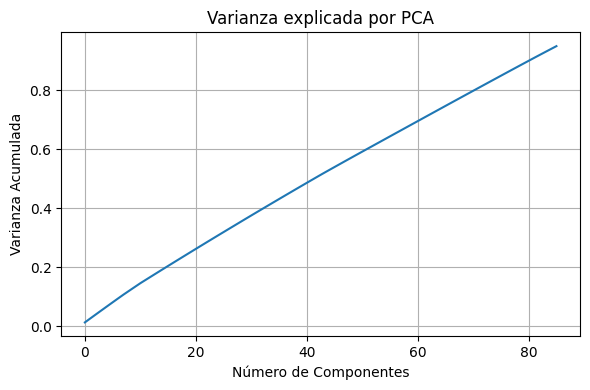

In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=0.95)
pca_features = pca.fit_transform(df_scaled.drop(columns=["User Rating"]))

print(f"Número de componentes retenidos: {pca.n_components_}")

# Gráfico de varianza explicada acumulada
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Acumulada")
plt.title("Varianza explicada por PCA")
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
pca.explained_variance_ratio_

array([0.01379217, 0.01369167, 0.01363857, 0.01358186, 0.01354246,
       0.013511  , 0.01342401, 0.01331096, 0.01273856, 0.01271536,
       0.01268176, 0.01176762, 0.01173313, 0.01171113, 0.01168636,
       0.0116402 , 0.01161521, 0.01156152, 0.01155139, 0.01151939,
       0.011511  , 0.01145044, 0.01144269, 0.01139322, 0.01136936,
       0.01132479, 0.01132173, 0.0112842 , 0.01128069, 0.01126804,
       0.01121898, 0.01117387, 0.01115183, 0.01109   , 0.01107989,
       0.01107133, 0.01104386, 0.01101555, 0.01099248, 0.01095331,
       0.01090848, 0.01088798, 0.01086503, 0.01078238, 0.01055969,
       0.01051596, 0.01049717, 0.01048222, 0.01042567, 0.01041441,
       0.01039358, 0.0103573 , 0.01035248, 0.01034963, 0.01034911,
       0.0103462 , 0.01033961, 0.01033406, 0.01033373, 0.01032605,
       0.01032391, 0.01031979, 0.01031181, 0.01030104, 0.01029347,
       0.01029029, 0.01028386, 0.01026745, 0.01025738, 0.01024455,
       0.01023686, 0.01023376, 0.01022347, 0.01022093, 0.01019

## 5. Selección de características mediante modelo

Se entrena un **árbol de decisión** para evaluar la importancia de las variables.  
Las menos relevantes pueden eliminarse en el paso siguiente.


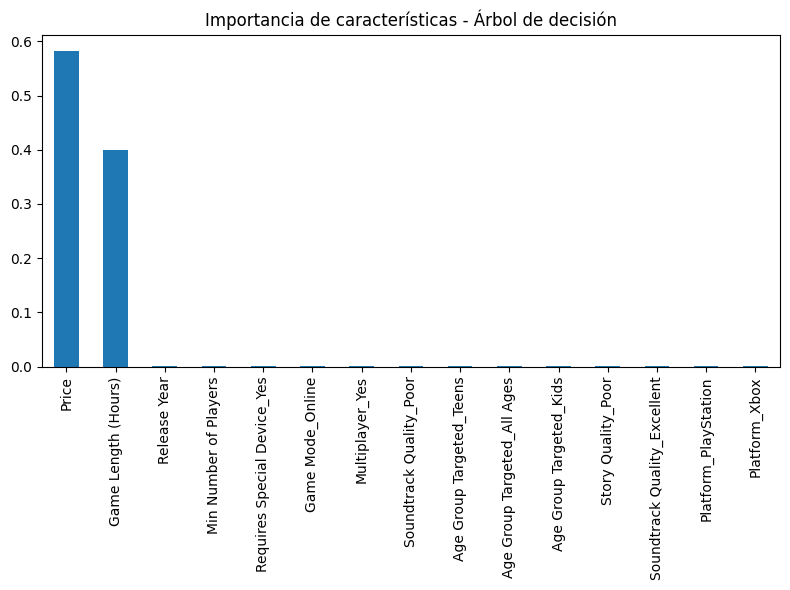

In [5]:
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

X = df_scaled.drop(columns=["User Rating"])
y = df_scaled["User Rating"]

model = DecisionTreeRegressor(random_state=42)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Mostrar las más importantes
plt.figure(figsize=(8,6))
importances.head(15).plot(kind='bar')
plt.title("Importancia de características - Árbol de decisión")
plt.tight_layout()
plt.show()

## 6. División en conjuntos de entrenamiento, validación y prueba

El conjunto se divide en:
- **Train/Test (80% / 20%)**
- Luego, el conjunto de entrenamiento se subdivide en **Train2/Validation (80% / 20%)**

Se guardan los subconjuntos en archivos `.csv` para su posterior uso en modelos.


In [6]:
from sklearn.model_selection import train_test_split

# Separar variables
X = df_scaled.drop(columns=["User Rating"])
y = df_scaled["User Rating"]

# División Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# División Train2/Validation
X_train2, X_val, y_train2, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Guardar datasets
X_train2.to_csv("TrainX.csv", index=False)
y_train2.to_csv("TrainY.csv", index=False)
X_val.to_csv("ValidationX.csv", index=False)
y_val.to_csv("ValidationY.csv", index=False)
X_test.to_csv("TestX.csv", index=False)
y_test.to_csv("TestY.csv", index=False)

print("Archivos generados correctamente:")
print("TrainX.csv, TrainY.csv, ValidationX.csv, ValidationY.csv, TestX.csv, TestY.csv")


Archivos generados correctamente:
TrainX.csv, TrainY.csv, ValidationX.csv, ValidationY.csv, TestX.csv, TestY.csv
